
# Beyond the Rivalry: What Makes an Elite ODI Batter?
### Python final project notebook (batting half)

**Research question:** What batting traits are most strongly associated with elite ODI batting performance, and how do India and Pakistan compare on scoring speed?

**Dependent variables:** `strike_rate`, `average`  
**Independent variables:** `boundary_rate`, `century_rate`, `team`

**Data source:** Original source is Cricsheet ODI data. The working file in this notebook is `batting_stats.csv`, a processed ODI batting summary file derived from Cricsheet.


In [1]:

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.formula.api as smf

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

dark_green = '#0B5D1E'
mid_green = '#2E8B57'
gold = '#C9A227'
navy = '#1E3A8A'
pak_green = '#006600'
light_gray = '#E6E6E6'

fig_dir = 'figures'
os.makedirs(fig_dir, exist_ok=True)


## Load the data

In [2]:

df = pd.read_csv('batting_stats.csv')
df.head()


,batter,team,matches,innings,dismisals,not_out,runs,balls,fours,sixes,50s,100s,highest_score,strike_rate,average
0,A Aitken-Drummond,Scotland,8,8,8,0,78,114,13,0,0,0,22,68.42,9.75
1,A Ashok,New Zealand,1,1,1,0,10,12,2,0,0,0,10,83.33,10.00
2,A Athanaze,West Indies,17,17,17,0,405,537,46,9,2,0,66,75.42,23.82
3,A Bagai,Canada,24,24,21,3,614,995,63,1,5,0,87,61.71,29.24
4,A Balbirnie,Ireland,83,83,79,4,2628,3557,254,34,13,8,135,73.88,33.27


In [3]:
df.shape

(2505, 15)

## Create variables and keep established batters

In [4]:

df['boundary_runs'] = df['fours'] * 4 + df['sixes'] * 6
df['boundary_rate'] = np.where(df['runs'] > 0, df['boundary_runs'] / df['runs'] * 100, np.nan)
df['century_rate'] = np.where(df['innings'] > 0, df['100s'] / df['innings'] * 100, np.nan)
df['has_century'] = np.where(df['100s'] > 0, 'At least 1 century', 'No centuries')

qualified = df[df['runs'] >= 1000].copy()
qualified.shape


(334, 19)

## Summary statistics table built with a loop

In [5]:

metrics = ['runs', 'balls', 'strike_rate', 'average', 'boundary_rate', 'century_rate']

summary_rows = []
for col in metrics:
    summary_rows.append({
        'Variable': col,
        'Mean': qualified[col].mean(),
        'Median': qualified[col].median(),
        'Std. Dev.': qualified[col].std(),
        'Min': qualified[col].min(),
        'Max': qualified[col].max()
    })

summary_table = pd.DataFrame(summary_rows).set_index('Variable').round(2)
summary_table


,Mean,Median,Std. Dev.,Min,Max
Variable,,,,,
runs,"2,735.78","1,988.50","2,013.10","1,004.00","14,675.00"
balls,"3,357.51","2,551.50","2,353.18",805.00,"15,958.00"
strike_rate,81.41,80.15,12.19,49.04,131.00
average,34.89,34.46,8.74,13.31,72.21
boundary_rate,47.45,46.59,7.61,29.40,69.44
century_rate,4.64,3.66,4.11,0.00,20.69


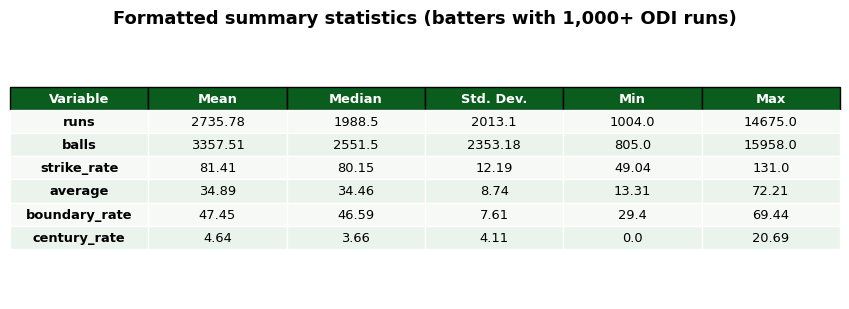

In [6]:

fig, ax = plt.subplots(figsize=(8.6, 3.2))
ax.axis('off')
tbl = ax.table(cellText=summary_table.reset_index().values,
               colLabels=['Variable', 'Mean', 'Median', 'Std. Dev.', 'Min', 'Max'],
               loc='center',
               cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9.4)
tbl.scale(1, 1.3)
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor(dark_green)
    else:
        if col == 0:
            cell.set_text_props(weight='bold')
        cell.set_facecolor('#F7F9F7' if row % 2 else '#EAF3EC')
        cell.set_edgecolor('white')
ax.set_title('Formatted summary statistics (batters with 1,000+ ODI runs)', fontsize=13, weight='bold', pad=10)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, 'summary_table.png'), bbox_inches='tight', facecolor='white')
plt.show()


## Bar chart: top 10 run scorers

In [7]:

top10 = df.sort_values('runs', ascending=False)[['batter', 'team', 'runs', 'average', 'strike_rate', '100s']].head(10)
top10


,batter,team,runs,average,strike_rate,100s
2396,V Kohli,India,14675,58.47,91.96,54
1126,KC Sangakkara,Sri Lanka,11640,46.19,79.38,24
1838,RG Sharma,India,11357,48.12,90.62,32
1462,MS Dhoni,India,10274,51.37,84.98,9
79,AB de Villiers,South Africa,9435,53.91,99.44,25
2318,TM Dilshan,Sri Lanka,9212,40.23,85.48,21
1292,LRPL Taylor,New Zealand,8126,46.70,80.94,20
578,DPMD Jayawardene,Sri Lanka,8069,33.48,78.58,12
815,HM Amla,South Africa,7834,48.66,86.49,26
2347,Tamim Iqbal,Bangladesh,7648,37.67,76.64,12


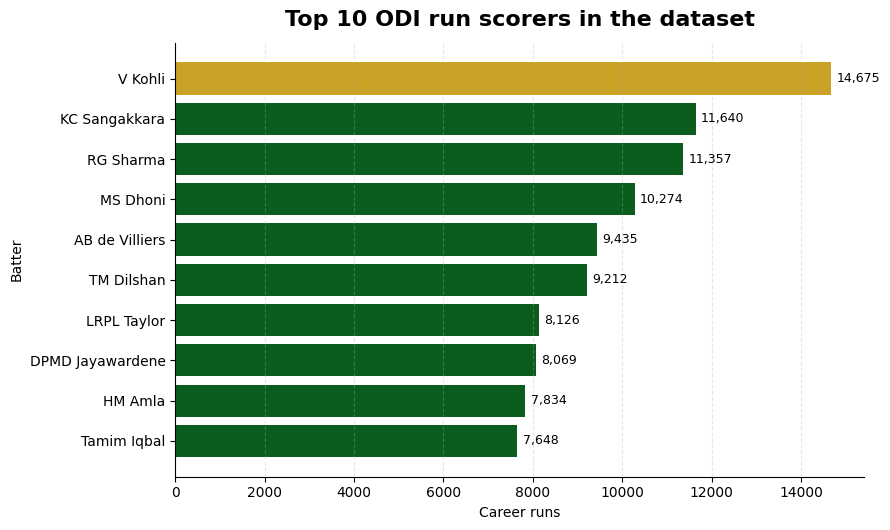

In [8]:

top10_plot = top10.sort_values('runs', ascending=True).copy()
colors = [gold if name == 'V Kohli' else dark_green for name in top10_plot['batter']]
fig, ax = plt.subplots(figsize=(9, 5.4))
bars = ax.barh(top10_plot['batter'], top10_plot['runs'], color=colors)
ax.set_title('Top 10 ODI run scorers in the dataset', fontsize=16, weight='bold', pad=12)
ax.set_xlabel('Career runs')
ax.set_ylabel('Batter')
ax.grid(axis='x', linestyle='--', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
for bar in bars:
    width = bar.get_width()
    ax.text(width + 120, bar.get_y() + bar.get_height()/2, f'{int(width):,}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, 'top10_runs.png'), bbox_inches='tight', facecolor='white')
plt.show()


## Histogram: strike-rate distribution

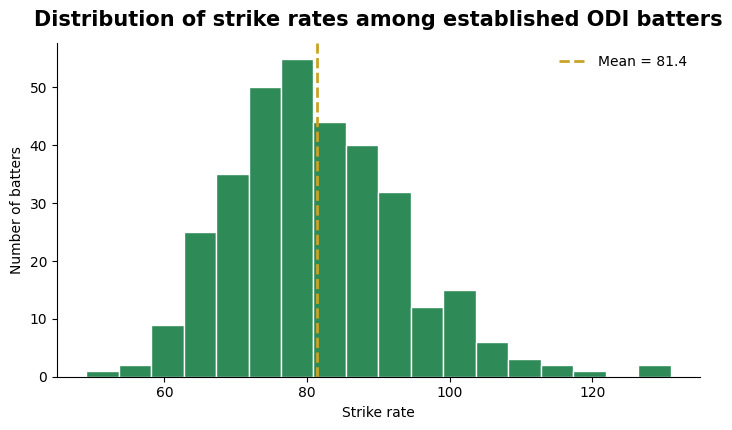

In [9]:

fig, ax = plt.subplots(figsize=(7.2, 4.4))
ax.hist(qualified['strike_rate'], bins=18, color=mid_green, edgecolor='white')
ax.axvline(qualified['strike_rate'].mean(), color=gold, linestyle='--', linewidth=2, label=f"Mean = {qualified['strike_rate'].mean():.1f}")
ax.set_title('Distribution of strike rates among established ODI batters', fontsize=15, weight='bold', pad=12)
ax.set_xlabel('Strike rate')
ax.set_ylabel('Number of batters')
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, 'strike_rate_hist.png'), bbox_inches='tight', facecolor='white')
plt.show()


## Groupby analysis: collapse to team level

In [10]:

major_teams = ['India', 'Pakistan', 'Australia', 'England', 'South Africa', 'New Zealand', 'Sri Lanka', 'West Indies', 'Bangladesh']

team_summary = (
    qualified[qualified['team'].isin(major_teams)]
    .groupby('team')
    .agg(
        players=('batter', 'count'),
        mean_runs=('runs', 'mean'),
        mean_sr=('strike_rate', 'mean'),
        mean_avg=('average', 'mean'),
        total_100s=('100s', 'sum')
    )
    .sort_values('mean_runs', ascending=False)
    .round(2)
)
team_summary


,players,mean_runs,mean_sr,mean_avg,total_100s
team,,,,,
India,31,"3,965.87",83.75,40.62,228
South Africa,28,"3,319.93",85.98,39.09,177
Australia,36,"3,097.56",87.36,39.48,182
Sri Lanka,30,"3,046.80",80.60,31.26,143
England,33,"2,900.33",86.03,37.67,166
Pakistan,32,"2,631.00",76.71,34.90,116
New Zealand,35,"2,403.09",85.22,34.46,136
Bangladesh,22,"2,396.68",73.38,28.62,61
West Indies,28,"2,394.29",81.03,31.46,106


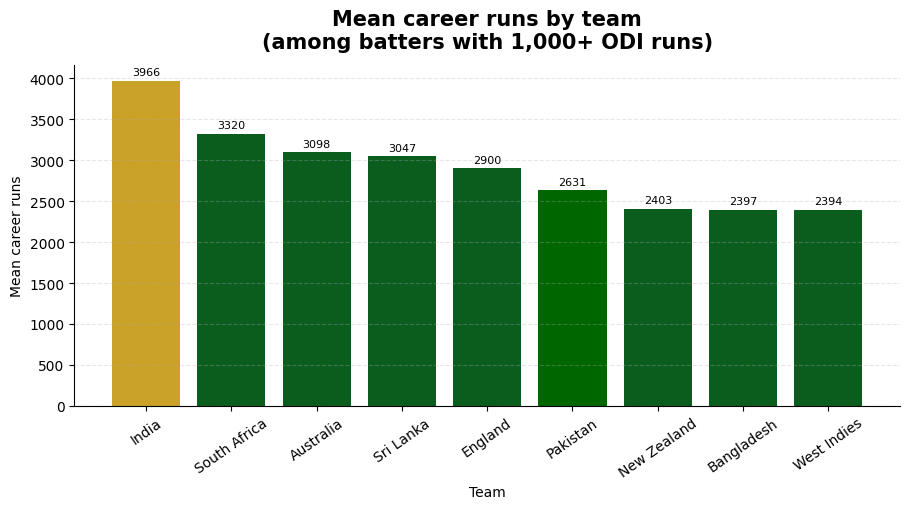

In [11]:

team_plot = team_summary.loc[['India', 'South Africa', 'Australia', 'Sri Lanka', 'England', 'Pakistan', 'New Zealand', 'Bangladesh', 'West Indies']]
bar_colors = [gold if t == 'India' else pak_green if t == 'Pakistan' else dark_green for t in team_plot.index]
fig, ax = plt.subplots(figsize=(9.2, 5.2))
bars = ax.bar(team_plot.index, team_plot['mean_runs'], color=bar_colors)
ax.set_title('Mean career runs by team\n(among batters with 1,000+ ODI runs)', fontsize=15, weight='bold', pad=12)
ax.set_xlabel('Team')
ax.set_ylabel('Mean career runs')
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='x', rotation=35)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 45, f"{bar.get_height():.0f}", ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, 'team_mean_runs.png'), bbox_inches='tight', facecolor='white')
plt.show()


## Crosstab

In [12]:

crosstab = pd.crosstab(
    qualified[qualified['team'].isin(major_teams)]['team'],
    qualified[qualified['team'].isin(major_teams)]['has_century']
)
crosstab


has_century,At least 1 century,No centuries
team,,
Australia,34,2
Bangladesh,17,5
England,30,3
India,24,7
New Zealand,27,8
Pakistan,25,7
South Africa,24,4
Sri Lanka,23,7
West Indies,23,5


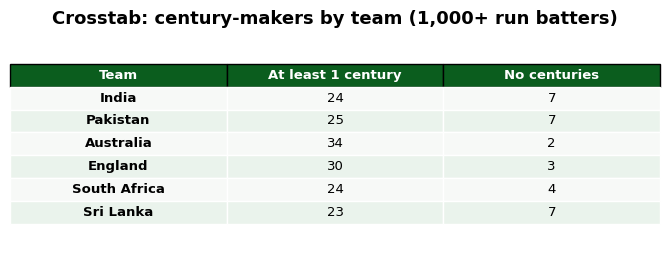

In [13]:

crosstab_slide = crosstab.loc[['India', 'Pakistan', 'Australia', 'England', 'South Africa', 'Sri Lanka']]
fig, ax = plt.subplots(figsize=(6.8, 2.7))
ax.axis('off')
tbl = ax.table(cellText=crosstab_slide.reset_index().values,
               colLabels=['Team', 'At least 1 century', 'No centuries'],
               loc='center',
               cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9.5)
tbl.scale(1, 1.35)
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor(dark_green)
    else:
        cell.set_facecolor('#F7F9F7' if row % 2 else '#EAF3EC')
        cell.set_edgecolor('white')
        if col == 0:
            cell.set_text_props(weight='bold')
ax.set_title('Crosstab: century-makers by team (1,000+ run batters)', fontsize=13, weight='bold', pad=10)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, 'crosstab_century.png'), bbox_inches='tight', facecolor='white')
plt.show()


## Difference in means test: India vs Pakistan strike rate

In [14]:

india_sr = qualified.loc[qualified['team'] == 'India', 'strike_rate']
pakistan_sr = qualified.loc[qualified['team'] == 'Pakistan', 'strike_rate']

t_stat, p_value = stats.ttest_ind(india_sr, pakistan_sr, equal_var=False, nan_policy='omit')

test_results = pd.DataFrame({
    'Group': ['India', 'Pakistan', 'Difference'],
    'Mean strike rate': [india_sr.mean(), pakistan_sr.mean(), india_sr.mean() - pakistan_sr.mean()],
    'Sample size': [india_sr.shape[0], pakistan_sr.shape[0], np.nan]
}).round(2)

print(f"t-statistic = {t_stat:.4f}")
print(f"p-value = {p_value:.4f}")
test_results


t-statistic = 2.1971
p-value = 0.0319


,Group,Mean strike rate,Sample size
0,India,83.75,31.00
1,Pakistan,76.71,32.00
2,Difference,7.04,NaN


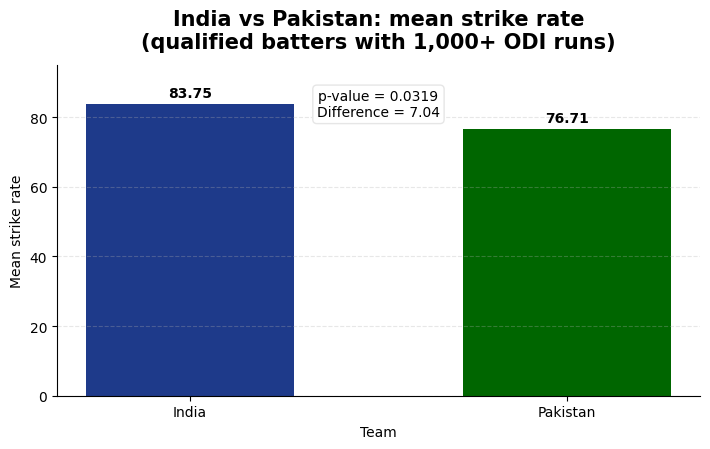

In [15]:

fig, ax = plt.subplots(figsize=(7.2, 4.6))
bars = ax.bar(['India', 'Pakistan'], [india_sr.mean(), pakistan_sr.mean()], color=[navy, pak_green], width=0.55)
ax.set_title('India vs Pakistan: mean strike rate\n(qualified batters with 1,000+ ODI runs)', fontsize=15, weight='bold', pad=12)
ax.set_xlabel('Team')
ax.set_ylabel('Mean strike rate')
ax.set_ylim(0, 95)
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 1.1, f'{h:.2f}', ha='center', va='bottom', fontsize=10, weight='bold')
ax.text(0.5, 88, f'p-value = {p_value:.4f}\nDifference = {india_sr.mean()-pakistan_sr.mean():.2f}',
        ha='center', va='top', fontsize=10,
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=light_gray))
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, 'india_pak_sr.png'), bbox_inches='tight', facecolor='white')
plt.show()


## Simple linear regression 1: strike rate on boundary rate

In [16]:

model_sr = smf.ols('strike_rate ~ boundary_rate', data=qualified).fit()
pd.DataFrame({'Coefficient': model_sr.params, 'p-value': model_sr.pvalues}).round(4)


,Coefficient,p-value
Intercept,37.78,0.00
boundary_rate,0.92,0.00


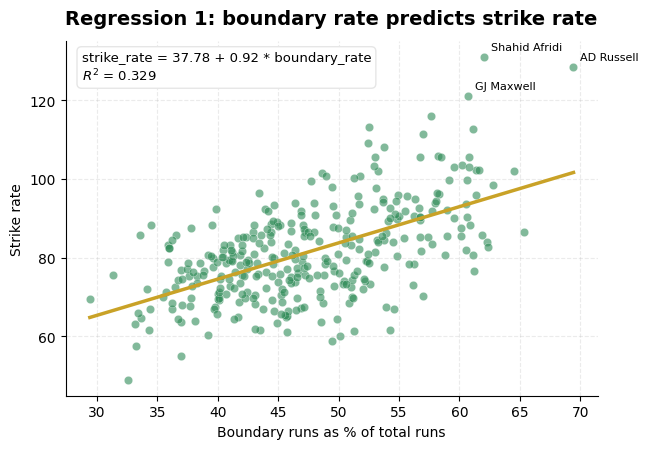

In [17]:

fig, ax = plt.subplots(figsize=(6.6, 4.6))
ax.scatter(qualified['boundary_rate'], qualified['strike_rate'], alpha=0.6, color=mid_green, edgecolor='white', linewidth=0.3)
x_line = np.linspace(qualified['boundary_rate'].min(), qualified['boundary_rate'].max(), 100)
y_line = model_sr.params['Intercept'] + model_sr.params['boundary_rate'] * x_line
ax.plot(x_line, y_line, color=gold, linewidth=2.5)
for name in ['Shahid Afridi', 'AD Russell', 'GJ Maxwell']:
    row = qualified[qualified['batter'] == name]
    if not row.empty:
        ax.annotate(name, (row['boundary_rate'].iloc[0], row['strike_rate'].iloc[0]), xytext=(5, 5), textcoords='offset points', fontsize=8)
ax.set_title('Regression 1: boundary rate predicts strike rate', fontsize=14, weight='bold', pad=12)
ax.set_xlabel('Boundary runs as % of total runs')
ax.set_ylabel('Strike rate')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(linestyle='--', alpha=0.25)
eq_text = f"strike_rate = {model_sr.params['Intercept']:.2f} + {model_sr.params['boundary_rate']:.2f} * boundary_rate\n$R^2$ = {model_sr.rsquared:.3f}"
ax.text(0.03, 0.97, eq_text, transform=ax.transAxes, va='top', bbox=dict(boxstyle='round,pad=0.35', fc='white', ec=light_gray), fontsize=9.5)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, 'reg_boundary_sr.png'), bbox_inches='tight', facecolor='white')
plt.show()


## Simple linear regression 2: batting average on century rate

In [18]:

model_avg = smf.ols('average ~ century_rate', data=qualified).fit()
pd.DataFrame({'Coefficient': model_avg.params, 'p-value': model_avg.pvalues}).round(4)


,Coefficient,p-value
Intercept,27.70,0.00
century_rate,1.55,0.00


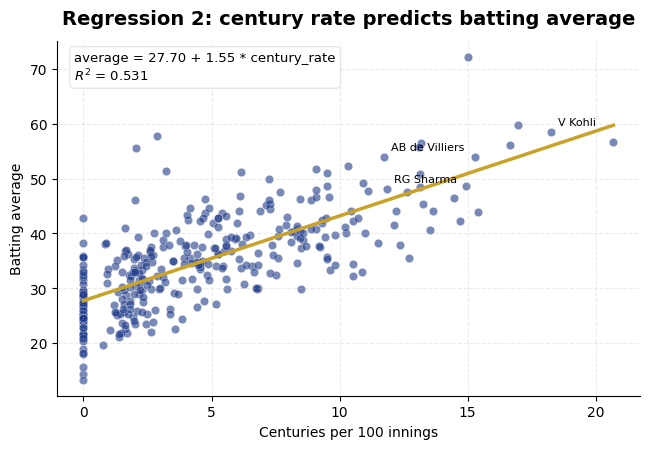

In [19]:

fig, ax = plt.subplots(figsize=(6.6, 4.6))
ax.scatter(qualified['century_rate'], qualified['average'], alpha=0.6, color=navy, edgecolor='white', linewidth=0.3)
x_line = np.linspace(qualified['century_rate'].min(), qualified['century_rate'].max(), 100)
y_line = model_avg.params['Intercept'] + model_avg.params['century_rate'] * x_line
ax.plot(x_line, y_line, color=gold, linewidth=2.5)
for name in ['V Kohli', 'AB de Villiers', 'RG Sharma']:
    row = qualified[qualified['batter'] == name]
    if not row.empty:
        ax.annotate(name, (row['century_rate'].iloc[0], row['average'].iloc[0]), xytext=(5, 5), textcoords='offset points', fontsize=8)
ax.set_title('Regression 2: century rate predicts batting average', fontsize=14, weight='bold', pad=12)
ax.set_xlabel('Centuries per 100 innings')
ax.set_ylabel('Batting average')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(linestyle='--', alpha=0.25)
eq_text = f"average = {model_avg.params['Intercept']:.2f} + {model_avg.params['century_rate']:.2f} * century_rate\n$R^2$ = {model_avg.rsquared:.3f}"
ax.text(0.03, 0.97, eq_text, transform=ax.transAxes, va='top', bbox=dict(boxstyle='round,pad=0.35', fc='white', ec=light_gray), fontsize=9.5)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, 'reg_century_avg.png'), bbox_inches='tight', facecolor='white')
plt.show()



## Final takeaway
- India has the highest mean career runs in this qualified sample.
- India's mean strike rate is significantly higher than Pakistan's in the qualified sample.
- Boundary rate predicts strike rate, and century rate predicts batting average.

### Partner handoff
My partner can continue with `bowling_stats.csv` and `all_rounder_stats.csv` from the same source for the bowling and all-rounder half of the presentation.
